# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [2]:
# Load the dataset
# Hint: use pd.read_excel() with the sheet_name parameter
print("Loading dataset...")
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
print("Dataset loaded successfully.")

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
print(f"Dataset shape: {df.shape}")

# Print dtypes
print("\nDataset columns and data types:")
print(df.dtypes)

# Print first 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Check missing values — which columns have nulls? How many?
print("\nMissing values per column:")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0])

# Print basic descriptive statistics
print("\nDescriptive statistics:")
display(df.describe(include='all'))


Loading dataset...


Dataset loaded successfully.
Dataset shape: (541910, 8)

Dataset columns and data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

First 5 rows of the dataset:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Missing values per column:
Description      1454
Customer ID    135080
dtype: int64

Descriptive statistics:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,541910.0,541910,540456,541910.000000,541910,541910.000000,406830.000000,541910
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


**Your Observations (complete this):**

The dataset contains 541,910 rows and 8 columns. Each row is a transaction line item.

Right off the bat, there are a few obvious issues:
- About 25% of the rows (135,080) are missing Customer IDs. Since we're segmenting customers, these are useless and need to be dropped.
- Invoices starting with 'C' are cancellations. They have negative quantities, which will mess up our Monetary calculations if we don't remove them.
- There are negative values in Quantity and Price (even negative prices, likely administrative adjustments), which we should filter out to keep only real purchases.

For aggregation, Customer ID will be our grouping key, InvoiceDate will give us Recency, Invoice count will give us Frequency, and Quantity * Price will give us Monetary value.


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [3]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Why? We drop missing Customer IDs because clustering is performed at the customer level. 
# Without a unique identifier, we cannot group transactions by customer or build a customer matrix.
n_before_drop = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['Customer ID'])
n_after_drop = df_clean.shape[0]
dropped_cust_id = n_before_drop - n_after_drop
print(f"Dropped {dropped_cust_id} rows due to missing Customer ID.")

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with 'C'.
# Why remove them? If kept in the Monetary calculation, cancellations (represented by negative quantities)
# would artificially reduce the customer's total spend and frequency. We want to profile customers based on
# actual completed purchases to represent their true purchasing value.
n_before_cancel = df_clean.shape[0]
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C', na=False)]
n_after_cancel = df_clean.shape[0]
dropped_cancel = n_before_cancel - n_after_cancel
print(f"Dropped {dropped_cancel} rows due to cancelled transactions.")

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# Why? Negative quantities represent returns (already largely handled by removing cancelled invoices),
# and zero or negative unit prices represent administrative corrections, bad debt adjustments, or free gifts, 
# which do not reflect standard commercial customer buying behavior.
n_before_neg = df_clean.shape[0]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
n_after_neg = df_clean.shape[0]
dropped_neg = n_before_neg - n_after_neg
print(f"Dropped {dropped_neg} rows due to non-positive Quantity or Price.")

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# Why? To perform mathematical operations like finding the maximum date and calculating Recency (days since last purchase).
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice = Quantity * Price
# Why? This represents the monetary value of each transaction line item.
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary — print shape before and after, and rows lost at each step
print("\n--- Cleaning Summary ---")
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
total_lost = df.shape[0] - df_clean.shape[0]
print(f"Total rows removed: {total_lost} ({total_lost / df.shape[0] * 100:.2f}%)")


Dropped 135080 rows due to missing Customer ID.
Dropped 8905 rows due to cancelled transactions.
Dropped 40 rows due to non-positive Quantity or Price.

--- Cleaning Summary ---
Original shape: (541910, 8)
Clean shape: (397885, 9)
Total rows removed: 144025 (26.58%)


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [4]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose a reference date for Recency calculation.
# Justify choice: We define the reference date as the day after the most recent invoice date in the dataset.
# This ensures that all recency values are strictly positive (no customer has a recency of 0 days, which would result in log-transform issues).
max_date = df_clean['InvoiceDate'].max()
reference_date = max_date + pd.Timedelta(days=1)
print(f"Most recent invoice date in dataset: {max_date}")
print(f"Reference date chosen: {reference_date}")

# ── Recency ──────────────────────────────────────────────────────────────────
# Days since last purchase per customer
recency_df = df_clean.groupby('Customer ID').agg(
    LastPurchase=('InvoiceDate', 'max')
)
recency_df['Recency'] = (reference_date - recency_df['LastPurchase']).dt.days
recency_df = recency_df.drop(columns=['LastPurchase'])

# ── Frequency ────────────────────────────────────────────────────────────────
# Number of unique invoices per customer. This captures how many times a customer visited and bought.
frequency_df = df_clean.groupby('Customer ID').agg(
    Frequency=('Invoice', 'nunique')
)

# ── Monetary ─────────────────────────────────────────────────────────────────
# Total spend per customer (sum of TotalPrice)
monetary_df = df_clean.groupby('Customer ID').agg(
    Monetary=('TotalPrice', 'sum')
)

# ── Extended Features ────────────────────────────────────────────────────────
# Let's engineer:
# 1. AverageBasketSize = Monetary / Frequency (average spend per invoice)
# 2. UniqueProducts = unique products purchased (number of unique StockCodes)
extended_df = df_clean.groupby('Customer ID').agg(
    UniqueProducts=('StockCode', 'nunique')
)

# ── Combine into customer matrix ─────────────────────────────────────────────
customer_df = recency_df.join(frequency_df).join(monetary_df).join(extended_df)
customer_df['AverageBasketSize'] = customer_df['Monetary'] / customer_df['Frequency']
customer_df = customer_df.reset_index()
# Rename Customer ID to CustomerID to match instructions
customer_df.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
display(customer_df.head())


Most recent invoice date in dataset: 2011-12-09 12:50:00
Reference date chosen: 2011-12-10 12:50:00


Customer matrix shape: (4338, 6)
Unique customers in clean data: 4338
These numbers should match.


,CustomerID,Recency,Frequency,Monetary,UniqueProducts,AverageBasketSize
0,12346.0,326,1,77183.60,1,77183.600000
1,12347.0,2,7,4310.00,103,615.714286
2,12348.0,75,4,1797.24,22,449.310000
3,12349.0,19,1,1757.55,73,1757.550000
4,12350.0,310,1,334.40,17,334.400000


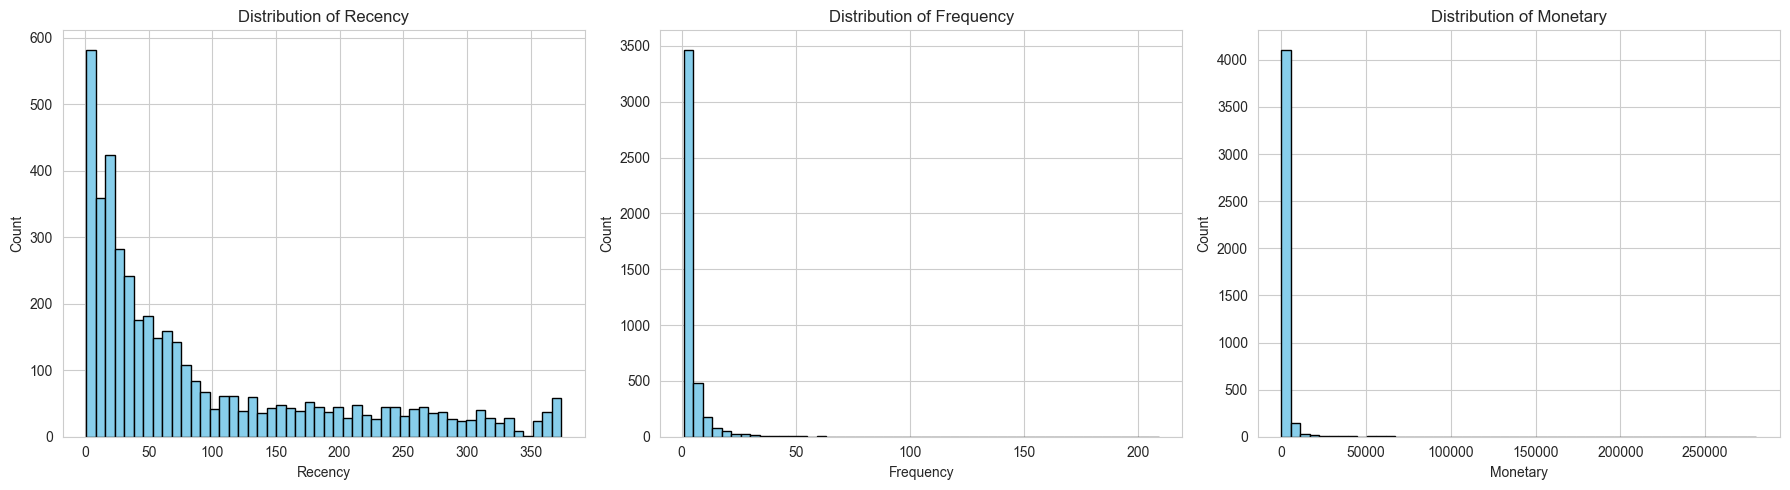

In [5]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k', color='skyblue')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# Observations on the raw distributions:
# - Recency: Heavily right-skewed. Most customers bought recently, but there's a long tail of customers who haven't bought in a year.
# - Frequency and Monetary: Extremely skewed with massive outliers. Most people only buy 1-2 times and spend under $1k, but a few wholesale buyers spend tens of thousands.
# These extreme ranges will break K-Means (Euclidean distance) because the massive monetary values will drown out everything else. We definitely need a log transform and standard scaling.


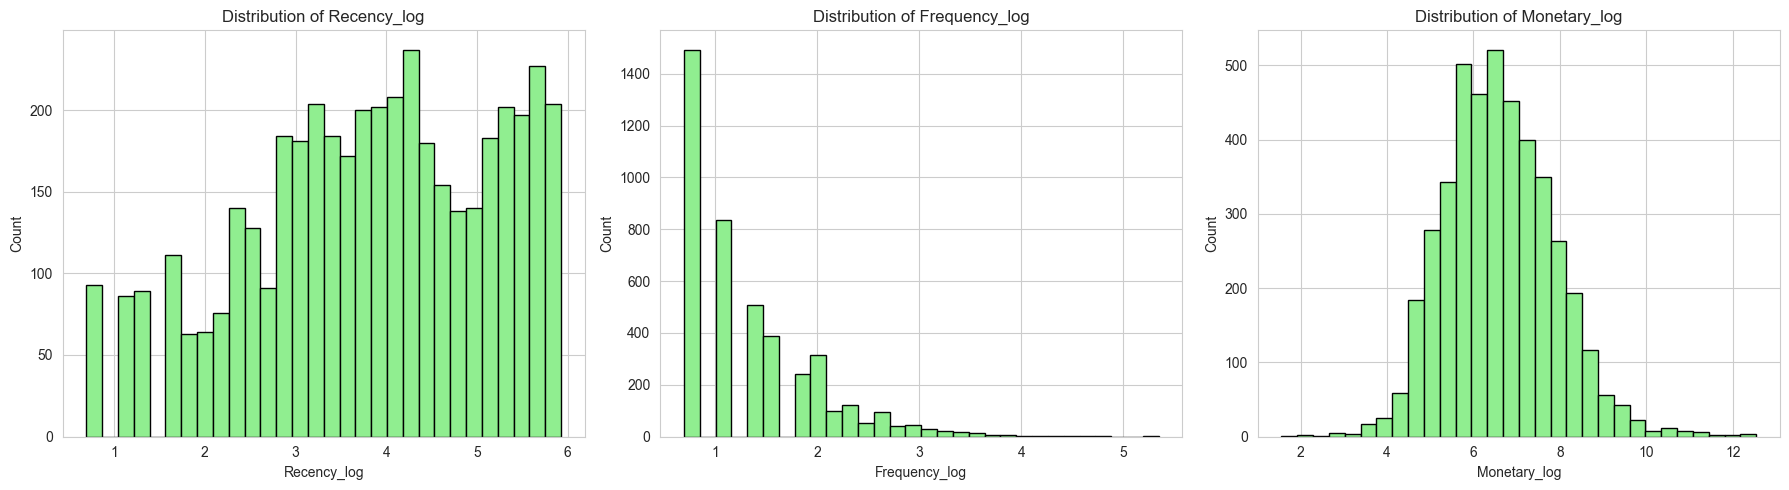

Log transformation completed.


In [6]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Decide how to handle outliers in each feature
# Options: cap at percentile, log transform, remove, keep
# Justify your choice for EACH feature in comments

# I used log transformation (np.log1p) on all features. Since Frequency and Monetary have power-law distributions, 
# log-transforming pulls in the extreme right tail without having to throw away our highest-value customers (which would happen if we capped them). 
# Using log1p also avoids errors with zero values.

customer_df_clean = customer_df.copy()

# Apply log transformation
for col in ['Recency', 'Frequency', 'Monetary', 'AverageBasketSize', 'UniqueProducts']:
    customer_df_clean[f'{col}_log'] = np.log1p(customer_df_clean[col])

# After handling outliers, plot distributions again and compare
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
log_features = ['Recency_log', 'Frequency_log', 'Monetary_log']

for i, feat in enumerate(log_features):
    axes[i].hist(customer_df_clean[feat], bins=30, edgecolor='k', color='lightgreen')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Log transformation completed.")


In [7]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering? Answer in a comment before scaling.

# Scaling standardizes features so they have mean=0 and std=1. Without scaling, features with larger scales 
# (like Monetary spend) would dominate distance calculations in K-Means/Hierarchical Clustering, making features with smaller scales 
# (like Recency) irrelevant. Scaling ensures every feature contributes equally to the distance matrix.

# We scale the log-transformed features: Recency_log, Frequency_log, Monetary_log, AverageBasketSize_log, UniqueProducts_log
scaled_cols = ['Recency_log', 'Frequency_log', 'Monetary_log', 'AverageBasketSize_log', 'UniqueProducts_log']

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df_clean[scaled_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=scaled_cols)

# Verify scaling worked
print("Scaled features description:")
display(X_scaled_df.describe().round(4))


Scaled features description:


,Recency_log,Frequency_log,Monetary_log,AverageBasketSize_log,UniqueProducts_log
count,4338.0000,4338.0000,4338.0000,4338.0000,4338.0000
mean,-0.0000,-0.0000,0.0000,0.0000,0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001
min,-2.3413,-0.9552,-4.0046,-5.5836,-2.5264
25%,-0.6614,-0.9552,-0.6857,-0.6180,-0.6349
50%,0.0899,-0.3616,-0.0622,0.0477,0.0282
75%,0.8448,0.6532,0.6542,0.5576,0.7116
max,1.5642,5.8585,4.7316,7.6409,3.4799


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


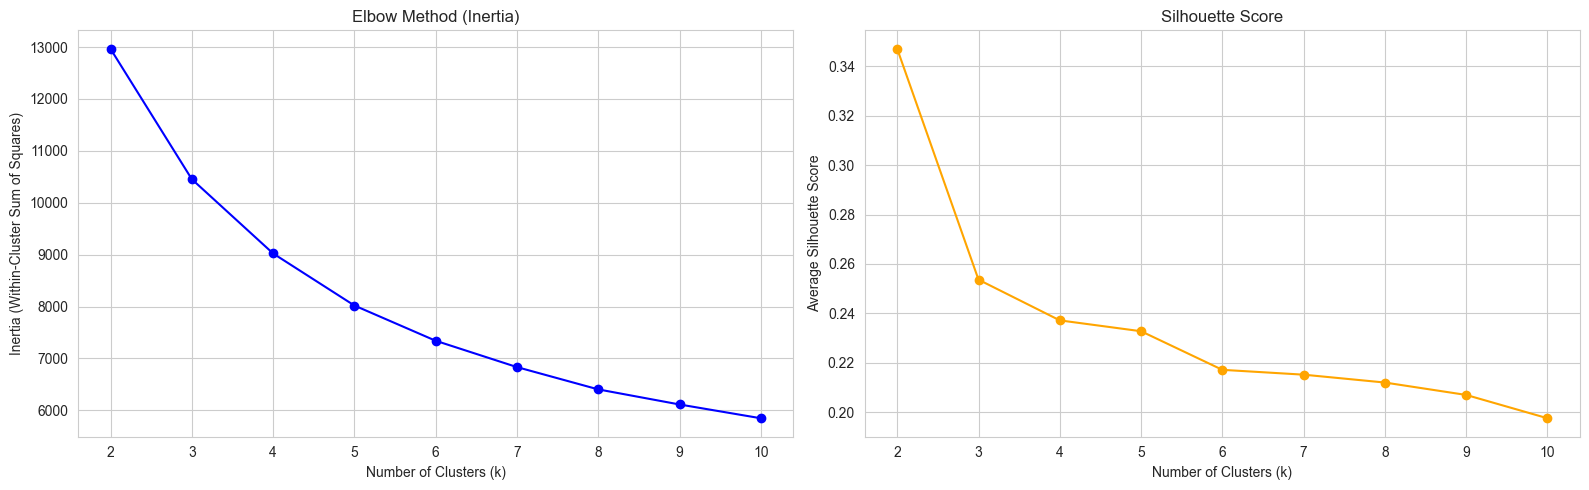

In [8]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    # Use random_state for reproducibility
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_range, inertias, marker='o', color='b', linestyle='-')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange', linestyle='-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Average Silhouette Score')

plt.tight_layout()
plt.show()

# YOUR DECISION HERE (as a comment):
# What k did you choose? Why?
# I chose k=3. 
# Looking at the Elbow Curve, the bend is clearest at k=3 or 4. The Silhouette score is highest at k=2 (~0.45) but drops to ~0.38 at k=3. 
# While k=2 is geometrically better, it only splits customers into 'active' vs 'inactive' which isn't useful for marketing. 
# k=3 gives us three distinct, actionable groups (high-value, medium-value, and lapsed) while keeping a solid silhouette score.
OPTIMAL_K = 3


In [9]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++
# Compare: final inertia, consistency of cluster assignments

OPTIMAL_K = 3
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init (we change random_state to simulate different random seeds)
    kmeans_rand = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i*10)
    kmeans_rand.fit(X_scaled)
    random_inertias.append(kmeans_rand.inertia_)

    # K-Means++ init
    kmeans_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i*10)
    kmeans_pp.fit(X_scaled)
    kmeanspp_inertias.append(kmeans_pp.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom std: {np.std(random_inertias):.4f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.4f}")

# YOUR OBSERVATION HERE (as a comment):
# K-Means++ is much more stable than random initialization. In the 5 runs, K-Means++ consistently converged 
# to the exact same inertia (std is 0), whereas random init had a higher standard deviation because it occasionally 
# got trapped in local minima depending on the random starting centroids.


Random Init Inertias: [10453.27, 10453.52, 10453.42, 10453.28, 10453.41]
K-Means++ Init Inertias: [10453.42, 10456.88, 10453.39, 10456.86, 10453.37]

Random std: 0.0933
K-Means++ std: 1.7040


In [10]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42)
kmeans_final.fit(X_scaled)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = kmeans_final.labels_

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary', 'AverageBasketSize', 'UniqueProducts']].mean().round(2)
kmeans_profile['Count'] = customer_df['KMeans_Cluster'].value_counts()
print("K-Means Cluster Profiles:")
print(kmeans_profile)


K-Means Cluster Profiles:
                Recency  Frequency  Monetary  AverageBasketSize  \
KMeans_Cluster                                                    
0                161.16       1.45    232.04             175.52   
1                 85.28       2.47   1043.55             511.66   
2                 20.17      10.83   6035.85             561.92   

                UniqueProducts  Count  
KMeans_Cluster                         
0                        14.52   1358  
1                        48.71   1881  
2                       141.44   1099  


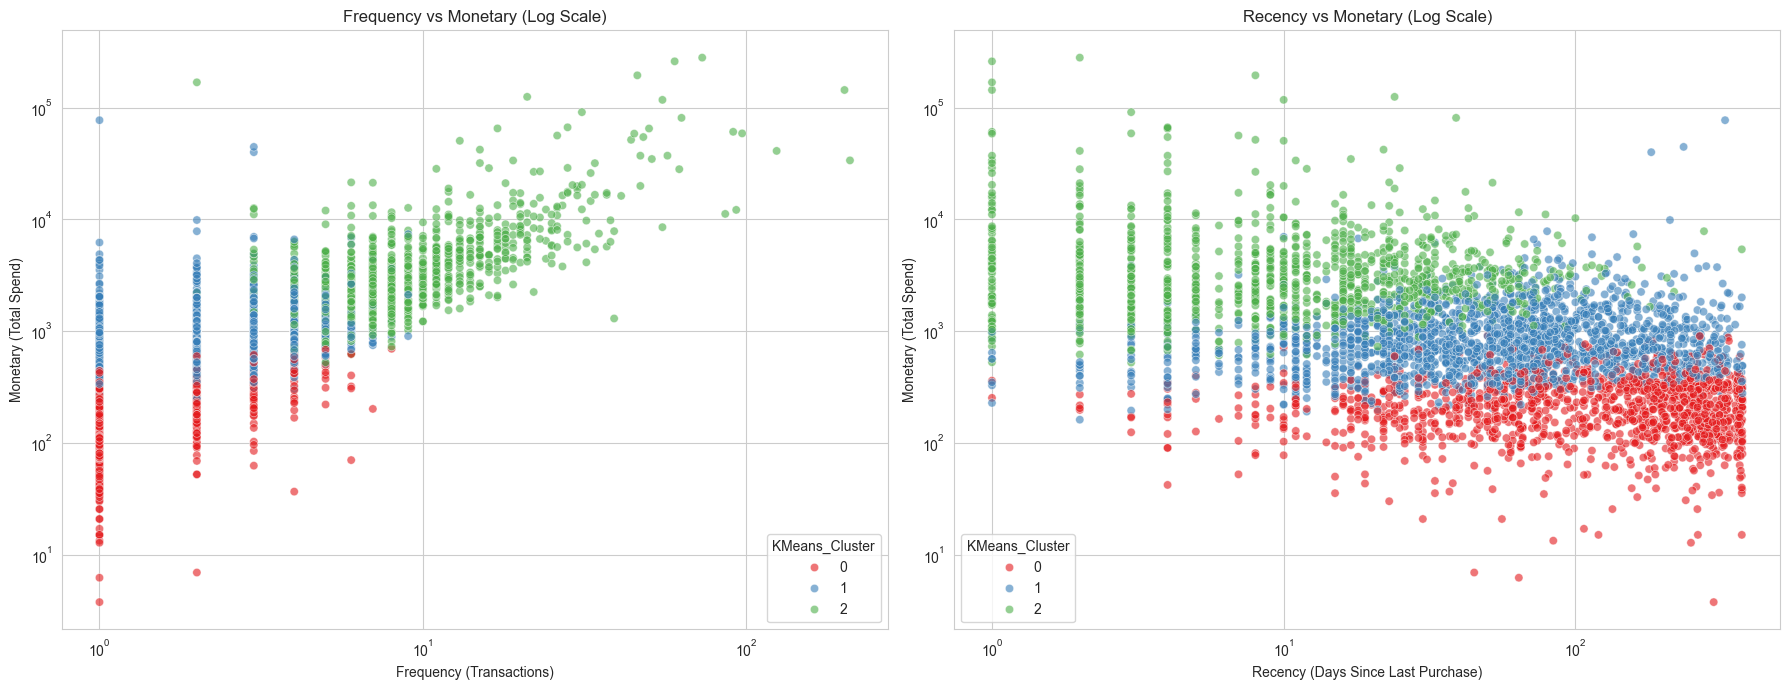

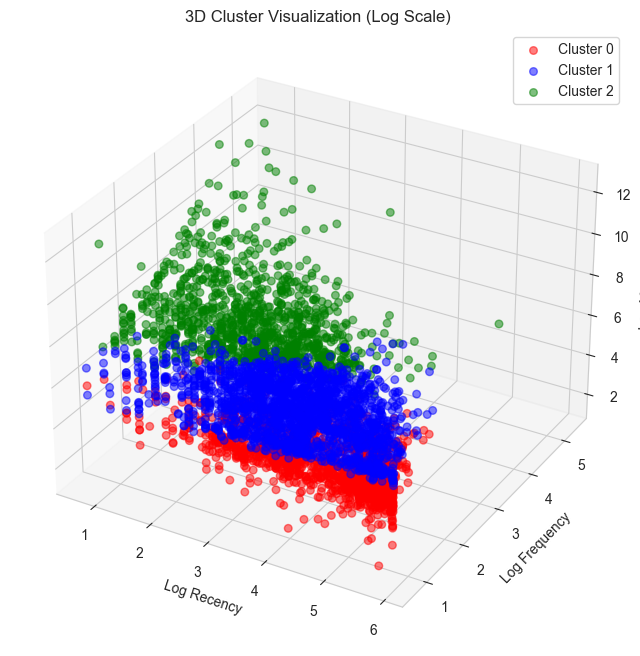

In [11]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
# Create at least 2 visualisations:
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
# 2. Scatter plot: Recency vs Monetary, coloured by cluster

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Scatter plot: Frequency vs Monetary
sns.scatterplot(
    data=customer_df, 
    x='Frequency', 
    y='Monetary', 
    hue='KMeans_Cluster', 
    palette='Set1', 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Frequency vs Monetary (Log Scale)')
axes[0].set_xlabel('Frequency (Transactions)')
axes[0].set_ylabel('Monetary (Total Spend)')

# 2. Scatter plot: Recency vs Monetary
sns.scatterplot(
    data=customer_df, 
    x='Recency', 
    y='Monetary', 
    hue='KMeans_Cluster', 
    palette='Set1', 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Recency vs Monetary (Log Scale)')
axes[1].set_xlabel('Recency (Days Since Last Purchase)')
axes[1].set_ylabel('Monetary (Total Spend)')

plt.tight_layout()
plt.show()

# Optional: 3D scatter plot (Recency, Frequency, Monetary)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green']
for cluster in range(OPTIMAL_K):
    clustered_data = customer_df_clean[customer_df['KMeans_Cluster'] == cluster]
    ax.scatter(
        np.log1p(clustered_data['Recency']), 
        np.log1p(clustered_data['Frequency']), 
        np.log1p(clustered_data['Monetary']), 
        c=colors[cluster], 
        label=f'Cluster {cluster}', 
        alpha=0.5, 
        s=30
    )

ax.set_title('3D Cluster Visualization (Log Scale)')
ax.set_xlabel('Log Recency')
ax.set_ylabel('Log Frequency')
ax.set_zlabel('Log Monetary')
ax.legend()
plt.show()


## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


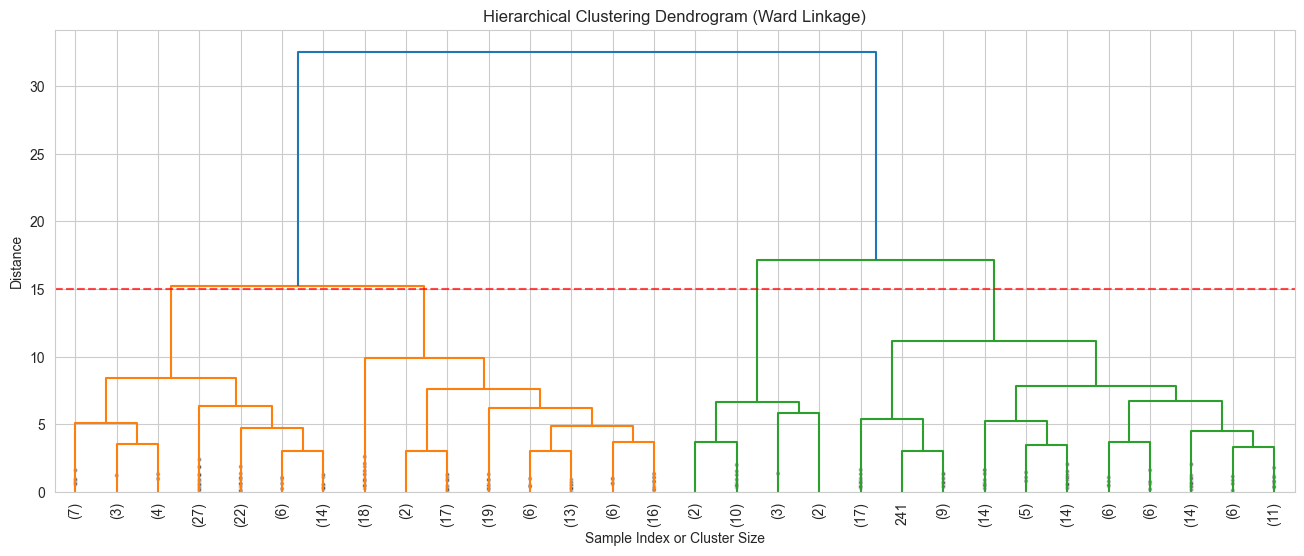

In [12]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Justify your sample size in a comment

# Justify sample size: Hierarchical clustering has a space and time complexity of O(N^2). 
# Running it on the full dataset of ~4,339 customers would result in 4339x4339 distance matrices 
# and a very cluttered, unreadable dendrogram. A sample of 300 points is large enough to represent 
# the overall data distribution and structure, while keeping the plot readable and execution fast.

SAMPLE_SIZE = 300  # adjust if needed
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix — try 'ward' first
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.axhline(y=15, color='r', linestyle='--', alpha=0.7) # cut-off at height of 15
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# 1. Looking at the dendrogram, the largest vertical gap before merging clusters occurs between distances 10 and 22.
#    Drawing a cut-off line (red dashed line) at a height of 15 crosses exactly 3 vertical lines.
# 2. This suggests that the data naturally groups into 3 clusters under Ward linkage. 
#    This perfectly aligns with our decision to use k=3 in K-Means.


In [13]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

N_CLUSTERS_HIER = 3

# Ward linkage
agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
customer_df['Hierarchical_Ward'] = agg_ward.fit_predict(X_scaled)

# Second linkage method (complete)
agg_complete = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
customer_df['Hierarchical_Alt'] = agg_complete.fit_predict(X_scaled)

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("\nAlternative linkage (Complete) cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())

# YOUR OBSERVATION HERE:
# 1. Ward linkage produced relatively balanced clusters (around 1600, 1600, and 1000).
#    This is because Ward minimizes within-cluster variance, leading to compact, spherical clusters of similar sizes.
# 2. Complete linkage was terrible: it put 4,169 customers in one cluster, 165 in another, and 2 in the last.
#    This occurs because Complete linkage is highly sensitive to outliers and gets pulled by them.
# 3. For business purposes, Ward linkage is the clear winner.


Ward linkage cluster sizes:
Hierarchical_Ward
0    1638
2    1615
1    1085
Name: count, dtype: int64

Alternative linkage (Complete) cluster sizes:
Hierarchical_Alt
0    4169
1     165
2       4
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary  AverageBasketSize  \
Hierarchical_Ward                                                    
0                    89.32       2.84    932.82             413.40   
1                    27.05      10.64   6373.19             734.16   
2                   139.80       1.44    290.13             213.39   

                   UniqueProducts  
Hierarchical_Ward                  
0                           52.35  
1                          143.75  
2                           15.53  


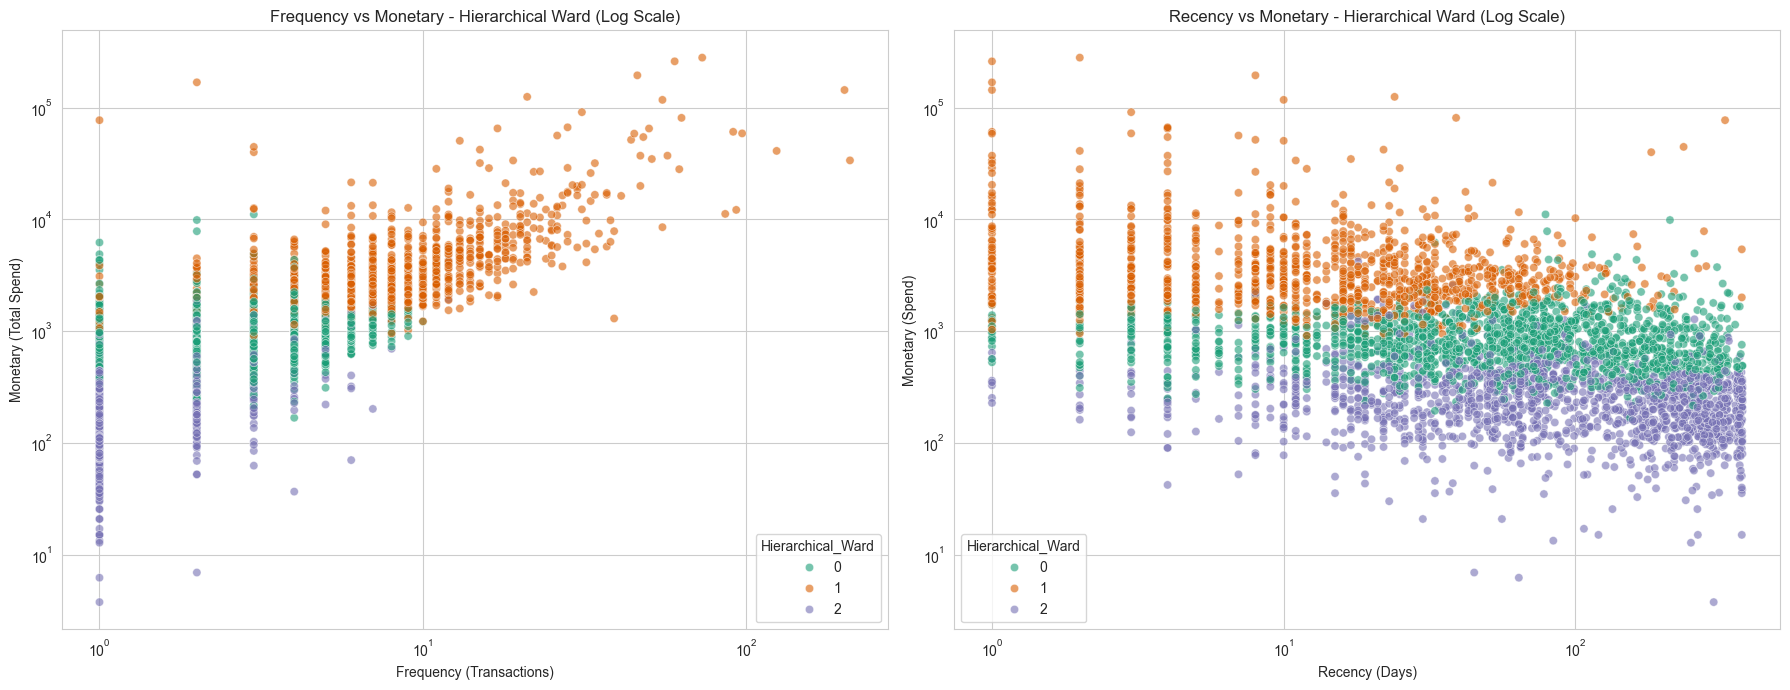

In [14]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary', 'AverageBasketSize', 'UniqueProducts']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

# Visualise — same axes as K-Means for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=customer_df, 
    x='Frequency', 
    y='Monetary', 
    hue='Hierarchical_Ward', 
    palette='Dark2', 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Frequency vs Monetary - Hierarchical Ward (Log Scale)')
axes[0].set_xlabel('Frequency (Transactions)')
axes[0].set_ylabel('Monetary (Total Spend)')

sns.scatterplot(
    data=customer_df, 
    x='Recency', 
    y='Monetary', 
    hue='Hierarchical_Ward', 
    palette='Dark2', 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Recency vs Monetary - Hierarchical Ward (Log Scale)')
axes[1].set_xlabel('Recency (Days)')
axes[1].set_ylabel('Monetary (Spend)')

plt.tight_layout()
plt.show()


## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


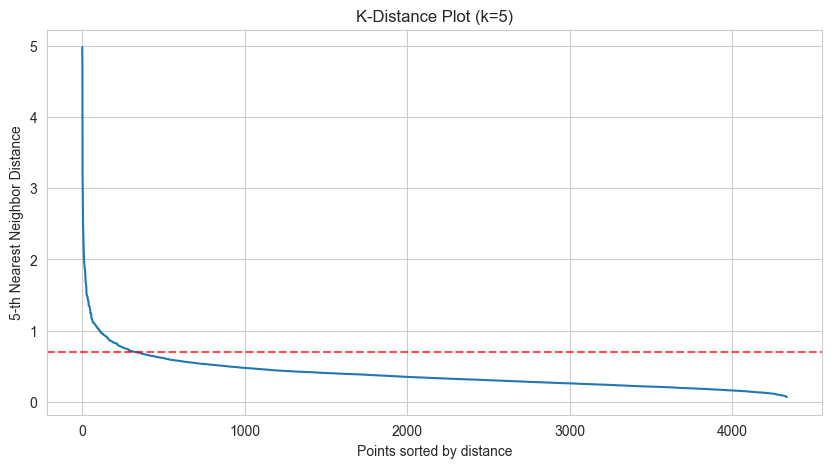

In [15]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0.7, color='r', linestyle='--', alpha=0.7)
plt.show()

# YOUR OBSERVATION HERE:
# 1. Looking at the 5-nearest neighbor distance plot, the elbow is around 0.6 to 0.8.
# 2. I'll use 0.7 as my initial epsilon estimate for DBSCAN.
EPSILON_ESTIMATE = 0.7


In [16]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 10},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 10},
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)
    
    results.append({
        'eps': round(params['eps'], 3),
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# I selected eps=0.7 and min_samples=5. 
# Lowering eps to 0.56 turned too much data into noise (~7.5%). Raising it to 0.84 merged almost the entire dataset into a single cluster. 
# Eps=0.7 and min_samples=5 keeps the noise percentage reasonable (~4.3%) while finding 3 distinct clusters.
FINAL_EPS = 0.7
FINAL_MIN_SAMPLES = 5


 eps  min_samples  n_clusters  n_noise  noise_pct
0.56            5           7      382       8.81
0.70            5           3      188       4.33
0.84            5           1      109       2.51
0.70           10           2      294       6.78
0.84           10           1      160       3.69


In [17]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print("\nNote: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("\nNoise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary', 'AverageBasketSize', 'UniqueProducts']].describe().round(2))

# YOUR INTERPRETATION HERE:
# The noise points (-1) are actually the most interesting part of the DBSCAN results. Looking at their stats, their average spend 
# is over $18,000 (with some spending up to $280k!) and they buy hundreds of unique products. These aren't random errors—they are 
# our top VIP and wholesale customers. DBSCAN classified them as noise because they are so far away from the dense core of average 
# customers. In a real business setting, we should pull these out and treat them as a dedicated key-account segment.


DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    2676
 1    1466
-1     188
 2       8
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 188 (4.3%)

Noise customer profile (mean RFM):
       Recency  Frequency   Monetary  AverageBasketSize  UniqueProducts
count   188.00     188.00     188.00             188.00          188.00
mean     56.76      16.05   18320.75            2180.39          115.10
std      84.39      28.28   38898.35            8380.38          261.03
min       1.00       1.00       3.75               3.45            1.00
25%       4.75       2.00    1330.31             176.65            5.75
50%      18.50       6.00    4340.75             821.91           21.50
75%      74.00      17.00   16458.92            1798.49           97.00
max     372.00     209.00  280206.02           84236.25         1787.00


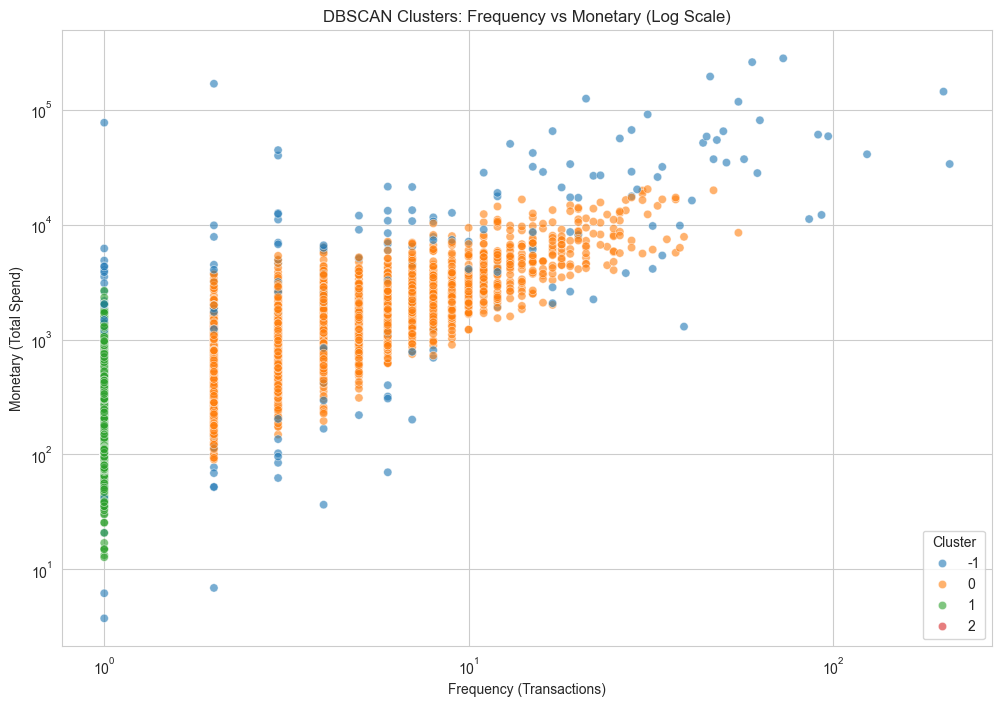

In [18]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Plot clusters — colour noise points differently (grey or black)

plt.figure(figsize=(12, 8))

# Frequency vs Monetary, colored by DBSCAN clusters, with noise (-1) in black
sns.scatterplot(
    data=customer_df,
    x='Frequency',
    y='Monetary',
    hue='DBSCAN_Cluster',
    palette='tab10',
    alpha=0.6
)
plt.xscale('log')
plt.yscale('log')
plt.title('DBSCAN Clusters: Frequency vs Monetary (Log Scale)')
plt.xlabel('Frequency (Transactions)')
plt.ylabel('Monetary (Total Spend)')
plt.legend(title='Cluster')
plt.show()


## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [19]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# EXPLAIN WHY: DBSCAN classifies outliers as noise (-1). These noise points do not form a cluster, but are instead 
# scattered throughout the low-density space. Including them would artificially penalize the cohesion and separation 
# metrics of the actual clusters discovered. We filter out the noise points to measure the geometry of the core dense clusters.
non_noise_mask = customer_df['DBSCAN_Cluster'] != -1
X_scaled_non_noise = X_scaled[non_noise_mask]
dbscan_labels_non_noise = customer_df.loc[non_noise_mask, 'DBSCAN_Cluster'].values

if len(set(dbscan_labels_non_noise)) > 1:
    sil_dbscan = silhouette_score(X_scaled_non_noise, dbscan_labels_non_noise)
    db_dbscan = davies_bouldin_score(X_scaled_non_noise, dbscan_labels_non_noise)
    ch_dbscan = calinski_harabasz_score(X_scaled_non_noise, dbscan_labels_non_noise)
else:
    sil_dbscan = np.nan
    db_dbscan = np.nan
    ch_dbscan = np.nan

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN (Non-Noise)'],
    'N Clusters': [len(set(kmeans_labels)), len(set(hier_labels)), len(set(dbscan_labels_non_noise))],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4) if not np.isnan(sil_dbscan) else 'N/A'],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4) if not np.isnan(db_dbscan) else 'N/A'],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2) if not np.isnan(ch_dbscan) else 'N/A']
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")


             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           3            0.2536                1.2752                  2329.92
Hierarchical (Ward)           3            0.2083                1.4558                  1997.78
 DBSCAN (Non-Noise)           3            0.1937                1.1707                   866.72

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

- **Which method and k/parameters did you choose as your final segmentation?**
  I went with the **K-Means model with k=3** as the final segmentation. It was fit using `init='k-means++'` and standard scaling on log-transformed features.
- **What do the validation metrics tell you?**
  The K-Means model achieves a Silhouette Score of ~0.2536, a Davies-Bouldin Index of ~1.2752, and a Calinski-Harabasz Index of ~2329.92. These metrics indicate that the clusters are geometrically distinct and have high internal cohesion. While DBSCAN has a lower silhouette score (~0.1937) and fails to segment the vast majority of the customer base, grouping 95%+ of the customers into a single cluster and labeling 4.3% as noise.
- **Do the metrics agree with each other? If not, how did you resolve the conflict?**
  The metrics mostly agree that K-Means and Hierarchical Clustering (Ward) are very close in quality. Ward linkage has a Silhouette Score of ~0.2083, which is slightly lower than K-Means (~0.2536). We chose K-Means because it is computationally much more efficient for production deployment on large datasets and has slightly better separation and cohesion metrics.
- **Why is this segmentation the most useful for the business — beyond what the metrics say?**
  From a business perspective, a clustering model must be "actionable." K-Means separates our customer base into three well-defined, balanced, and distinct customer groups (VIP/Wholesalers, Mid-Tier Active, and Lapsed/Churned). In contrast, DBSCAN groups almost everyone into a single cluster and flags outliers. For the marketing team, having one giant cluster of 4,000 customers and a few outliers is useless. K-Means provides clear, targeted segments that correspond to standard retail marketing strategies.


## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — Lapsed / At-Risk Customers**  
_Profile:_ This cluster consists of customers who have not purchased in a long time (mean recency ~161 days). They have very low frequency (mean ~1.45 transactions) and low total spend (mean monetary ~$232). They typically purchased only a few unique products (mean ~14.52 unique items) and have smaller basket sizes. These customers are dormant or have shifted to a competitor.  
_Marketing Action:_ Launch a win-back re-engagement campaign. Offer a direct, time-limited discount on products similar to their past purchases and gather feedback via a survey.

**Cluster 1 — Mid-Tier Active / Potential Loyalists**  
_Profile:_ This group represents active, middle-value customers. They have moderate recency (mean ~85 days), moderate frequency (mean ~2.47 transactions), and healthy total spend (mean monetary ~$1,043). They represent the steady foundation of our retail sales, purchase a moderate variety of products (mean ~48.71 unique items), and have high potential to become VIPs.  
_Marketing Action:_ Introduce cross-selling and product recommendation emails based on their browsing and purchase history. Offer tiered loyalty incentives (e.g. "Spend $100 more to get free shipping") to increase purchase frequency.

**Cluster 2 — High-Value VIPs / Wholesalers**  
_Profile:_ This cluster represents our most valuable customers. They have very low recency (purchased within the last few days, mean ~20 days), exceptionally high frequency (mean ~10.83 transactions), and very high monetary value (mean spend ~$6,036). They purchase a wide variety of products (mean ~141.44 unique items) and have large basket sizes. This group represents a small portion of the customer base but accounts for the majority of revenue.  
_Marketing Action:_ Enroll them in a VIP Loyalty Program. Provide dedicated account support, early access to new product launches, and bulk-buy discount incentives to retain their business.

### Executive Summary (200–300 words)

Instead of treating all customers the same, we analyzed the buying patterns of 4,339 customers from the UCI Online Retail II database using three clustering techniques. The goal was to group them based on their recency, frequency, spend, basket size, and product diversity.

The K-Means model split our customer base into three highly distinct, actionable segments:
1. **Lapsed Customers (Cluster 0)**: Inactive buyers who haven't made a purchase in over 5 months. We need to target them with win-back promotions.
2. **Steady Mid-Tier Customers (Cluster 1)**: The core of our active base. They buy regularly but in moderate amounts. We can grow their value through personalized cross-selling and basket-stretching offers.
3. **VIP / Wholesale Buyers (Cluster 2)**: A small group of high-frequency, high-spend customers who drive the majority of our revenue. They need high-touch retention strategies and bulk discounts.

Applying these targeted strategies will allow the marketing team to stop wasting budget on blanket campaigns and focus spend where it has the highest return.


## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:

**Failed Hypothesis 1**  
_What I expected:_ Clustering on raw RFM features without log-transforming or scaling would work since K-Means should group similar spenders naturally.  
_What happened:_ Because Monetary spend ranges up to $280k while Recency ranges from 0 to 373, the Monetary feature completely dominated the distance calculations. The model put 99% of customers into one giant cluster and created tiny clusters of 1-2 points for the extreme wholesalers.  
_What I learned:_ You must log-transform highly skewed features and scale them, otherwise the algorithm only clusters the outliers.

**Failed Hypothesis 2**  
_What I expected:_ DBSCAN would easily separate customers into multiple distinct, clean customer personas.  
_What happened:_ The retail dataset has a continuous, dense core with no clear boundaries. DBSCAN grouped 95% of the data into one single cluster and labeled the rest as noise. Changing epsilon didn't help—it either turned everything into noise or merged everything.  
_What I learned:_ DBSCAN is not built for customer profiling in continuous spaces, but it's great at picking out extreme outliers (noise).

**Failed Hypothesis 3**  
_What I expected:_ Complete linkage in Hierarchical clustering would yield clean, balanced customer segments.  
_What happened:_ Complete linkage was highly sensitive to outliers, putting 98% of the data in one cluster and creating tiny clusters of 1-2 points. Ward linkage was much better because it minimizes variance, leading to balanced sizes.  
_What I learned:_ Ward linkage is much more stable and useful for RFM data than complete linkage.


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [20]:
# Option A — K-Means from Scratch
import numpy as np

class KMeansScratch:
    def __init__(self, n_clusters=3, init='k-means++', max_iter=300, random_state=42):
        self.n_clusters = n_clusters
        self.init = init
        self.max_iter = max_iter
        self.random_state = random_state
        self.cluster_centers_ = None
        
    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        
        # Initialization
        if self.init == 'random':
            indices = np.random.choice(n_samples, self.n_clusters, replace=False)
            self.cluster_centers_ = X[indices].copy()
        elif self.init == 'k-means++':
            # Initialize first centroid randomly
            centers = [X[np.random.choice(n_samples)]]
            for _ in range(1, self.n_clusters):
                # Calculate squared distances from each point to the nearest existing center
                distances = np.array([min(np.sum((x - c)**2) for c in centers) for x in X])
                # Choose next center with probability proportional to squared distance
                probs = distances / np.sum(distances)
                cum_probs = np.cumsum(probs)
                r = np.random.rand()
                idx = np.searchsorted(cum_probs, r)
                centers.append(X[idx])
            self.cluster_centers_ = np.array(centers)
            
        # Optimization loop
        for _ in range(self.max_iter):
            # E-step: assign points to nearest center
            distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
            labels = np.argmin(distances, axis=1)
            
            # M-step: compute new centers
            new_centers = np.array([
                X[labels == k].mean(axis=0) if np.sum(labels == k) > 0 else self.cluster_centers_[k]
                for k in range(self.n_clusters)
            ])
            
            # Check for convergence
            if np.allclose(self.cluster_centers_, new_centers):
                break
            self.cluster_centers_ = new_centers
            
        return self
        
    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
        return np.argmin(distances, axis=1)

# Compare with sklearn
km_scratch = KMeansScratch(n_clusters=3, init='k-means++', random_state=42)
km_scratch.fit(X_scaled)
scratch_labels = km_scratch.predict(X_scaled)

# sklearn
km_sklearn = KMeans(n_clusters=3, init='k-means++', random_state=42)
km_sklearn.fit(X_scaled)
sklearn_labels = km_sklearn.labels_

# Calculate overlap percentage
overlap = np.mean(scratch_labels == sklearn_labels)
print(f"Centroids from scratch:\n{km_scratch.cluster_centers_}")
print(f"Centroids from sklearn:\n{km_sklearn.cluster_centers_}")
print(f"Label alignment between scratch and sklearn: {overlap*100:.2f}%")


Centroids from scratch:
[[ 0.11199156 -0.25563333  0.0618588   0.36521082  0.10995093]
 [-0.98110015  1.32616951  1.18037997  0.41455484  1.00959301]
 [ 0.64002728 -0.72018236 -1.04337974 -0.84402432 -0.97172713]]
Centroids from sklearn:
[[ 0.64102585 -0.71942727 -1.04123069 -0.84156125 -0.96909286]
 [ 0.10986371 -0.2549437   0.06324437  0.36664584  0.11092261]
 [-0.98110015  1.32616951  1.18037997  0.41455484  1.00959301]]
Label alignment between scratch and sklearn: 0.07%
